# 13 - Pipeline `dire-recon` (Optuna-tuned)

DDIM invert+reconstruct with SD v1.5; the reconstruction-error map (DIRE) is classified by a CNN. Needs `diffusers`+`accelerate`; DIRE maps are computed on a subsample and cached, then the classifier is tuned with Optuna (DDIM `STEPS` fixed).

**Sections:** 0 Setup - 1 Data - 2 Hyperparameter search (Optuna) - 3 Final train - 4 Curves - 5 In-dist eval - 6 OOD preview - 7 Explainability - 8 metrics.json

Training is **Optuna-driven**: a search maximizes val AUC (with pruning), the winner is saved, and the final model is trained on it. Set `TUNE=False` to skip the search and reuse the committed `best_params.json`. Artifacts -> `notebooks/artifacts/dire-recon/{models,figures,metrics,tuning}`.

## 0 - Setup

In [1]:
import sys, time, json, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
import optuna

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda, tuning as TU
from utils.paths import repo_paths, artifact_dirs

optuna.logging.set_verbosity(optuna.logging.WARNING)
torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

from utils import dire as DR

PIPELINE = "dire-recon"
WORKING_SIZE = 224
NORM = "imagenet"
BATCH_SIZE = 64
STEPS = 20
DIRE_BATCH = 4
TUNE = True
N_TRIALS = 20
SEARCH_EPOCHS = 8
FINAL_EPOCHS = 12
WARMUP_EPOCHS = 1
N_TRAIN, N_VAL, N_TEST, N_OOD = 4000, 800, 2000, 2000
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE)

device: cuda | pipeline: dire-recon


## (GPU clean)

In [2]:
# Clear the GPU at the very start (frees this process's CUDA cache + reports free VRAM).
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU cleaned - free {free_b / 1e9:.1f} / {total_b / 1e9:.1f} GB")
else:
    print("CPU mode - nothing to clean")

GPU cleaned - free 11.8 / 12.9 GB


## 1 - Build / cache DIRE maps

In [3]:
def subsample(df, n, seed=42):
    per = n // 2
    parts = [df[df["label"] == lab].sample(min(per, int((df["label"] == lab).sum())), random_state=seed) for lab in ["real", "fake"]]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def build_dire_cache(df, out_npy):
    out = Path(out_npy)
    if out.exists():
        return np.load(out)
    pipe, fwd, inv = DR.load_dire_pipeline(steps=STEPS, device=str(device))
    paths = df["filepath"].tolist(); maps = []
    for i in range(0, len(paths), DIRE_BATCH):
        x = torch.stack([DR.read_512(p) for p in paths[i:i + DIRE_BATCH]])
        maps.append(DR.dire_to_uint8(DR.compute_dire(x, pipe, fwd, inv)))
        if (i // DIRE_BATCH) % 25 == 0:
            print(f"  {i}/{len(paths)}")
    arr = np.concatenate(maps); np.save(out, arr); return arr

ms = pd.read_csv(SPLIT_PATH); ms = ms[ms["keep"]]
subs = {"train": subsample(ms[ms["split_final"] == "train"], N_TRAIN), "val": subsample(ms[ms["split_final"] == "val"], N_VAL), "test": subsample(ms[ms["split_final"] == "test"], N_TEST)}
DIRE, LAB = {}, {}
for split, df in subs.items():
    DIRE[split] = build_dire_cache(df, AIR_DIR / f"dire_{split}.npy")
    LAB[split] = (df["label"].values == "fake").astype(np.float32)
    print(f"{split}: {DIRE[split].shape}")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  1700/2000


  1800/2000


  1900/2000


test: (2000, 256, 256, 3)


## 2 - Dataset over cached DIRE maps + Optuna search

In [4]:
class DireDataset(torch.utils.data.Dataset):
    def __init__(self, arr, labels, tf):
        self.arr, self.labels, self.tf = arr, labels, tf
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        t = torch.from_numpy(np.array(self.arr[i])).permute(2, 0, 1).contiguous()
        return self.tf(t), self.labels[i]

mean, std = D.IMAGENET_MEAN, D.IMAGENET_STD
train_tf = D.build_train_tf(WORKING_SIZE, mean, std); eval_tf = D.build_eval_tf(WORKING_SIZE, mean, std)
def mk(split, tf, sh, bs):
    return torch.utils.data.DataLoader(DireDataset(DIRE[split], LAB[split], tf), batch_size=bs, shuffle=sh)
train_loader = mk("train", train_tf, True, BATCH_SIZE); val_loader = mk("val", eval_tf, False, BATCH_SIZE * 2); test_loader = mk("test", eval_tf, False, BATCH_SIZE * 2)

SEARCH_SPACE = {
    "backbone": {"type": "categorical", "choices": ["efficientnet_b0", "resnet50"]},
    "p_drop": {"type": "float", "low": 0.1, "high": 0.5},
    "lr": {"type": "loguniform", "low": 1e-4, "high": 1e-3},
    "weight_decay": {"type": "loguniform", "low": 1e-5, "high": 1e-3},
    "label_smooth": {"type": "float", "low": 0.0, "high": 0.1},
    "loss": {"type": "categorical", "choices": ["bce", "focal"]},
}
DEFAULTS = {"backbone": "efficientnet_b0", "p_drop": 0.3, "lr": 3e-4, "weight_decay": 1e-4, "label_smooth": 0.05, "loss": "bce"}

def objective(trial):
    p = {
        "backbone": trial.suggest_categorical("backbone", ["efficientnet_b0", "resnet50"]),
        "p_drop": trial.suggest_float("p_drop", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "label_smooth": trial.suggest_float("label_smooth", 0.0, 0.1),
        "loss": trial.suggest_categorical("loss", ["bce", "focal"]),
    }
    gamma = trial.suggest_float("focal_gamma", 1.0, 3.0) if p["loss"] == "focal" else 2.0
    model = M.build_cnn_finetune(p["backbone"], pretrained=True, p_drop=p["p_drop"]).to(device, memory_format=torch.channels_last)
    try:
        return TU.quick_train_eval(model, train_loader, val_loader, device, lr=p["lr"], weight_decay=p["weight_decay"],
                                   epochs=SEARCH_EPOCHS, trial=trial, loss_fn=TU.make_loss(p["loss"], gamma), label_smooth=p["label_smooth"])
    finally:
        TU.cleanup(model)

def _cb(study, trial):
    v = trial.value if trial.value is not None else float("nan")
    print(f"  trial {trial.number:02d}: {trial.state.name:8s} value={v:.4f}")

TUNE_SUMMARY = {"tuned": bool(TUNE), "search_space": SEARCH_SPACE}
if TUNE:
    study = TU.make_study(PIPELINE, dirs["models"].parent / "tuning")
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb], gc_after_trial=True)
    TU.save_study_artifacts(study, SEARCH_SPACE, dirs["figures"], dirs["metrics"])
    best = {**DEFAULTS, **study.best_params}
    TUNE_SUMMARY.update(n_trials=len(study.trials), best_val_auc=float(study.best_value), best_params=best)
    print("\nBEST:", best, "| val_auc", round(study.best_value, 4))
else:
    best = TU.load_best_params(dirs["metrics"], DEFAULTS)
    TUNE_SUMMARY["best_params"] = best
    print("TUNE off -> using", best)

  trial 00: COMPLETE value=0.9334


  trial 01: COMPLETE value=0.9300


  trial 02: COMPLETE value=0.9173


  trial 03: COMPLETE value=0.9306


  trial 04: COMPLETE value=0.9240


...

  trial 18: PRUNED   value=0.9280


  trial 19: PRUNED   value=0.9085


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])



BEST: {'backbone': 'efficientnet_b0', 'p_drop': 0.2970702945812612, 'lr': 0.000619428307410396, 'weight_decay': 1.0139434690021975e-05, 'label_smooth': 0.009414835630156285, 'loss': 'bce'} | val_auc 0.9441


## 3 - Final train (best params)

In [5]:
model = M.build_cnn_finetune(best["backbone"], pretrained=True, p_drop=best["p_drop"]).to(device, memory_format=torch.channels_last)
loss_fn = TU.make_loss(best["loss"], best.get("focal_gamma", 2.0))
optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
spe = len(train_loader); scheduler = T.build_cosine_with_warmup(optimizer, total_steps=FINAL_EPOCHS * spe, warmup_steps=WARMUP_EPOCHS * spe)
stopper = T.EarlyStopper(mode="max", patience=6, min_delta=1e-3)
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
best_auc = -1.0; ckpt_path = dirs["models"] / "best.pt"
for epoch in range(FINAL_EPOCHS):
    tr = T.train_one_epoch(model, train_loader, optimizer, loss_fn, device, scheduler=scheduler, label_smooth=best["label_smooth"])
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]; T.save_weights(ckpt_path, model.state_dict(), meta={"pipeline": PIPELINE, "kind": "dire_classifier", "steps": STEPS, **best})
    print(f"epoch {epoch+1:02d} | val_auc {vm['auc_roc']:.4f}{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

epoch 01 | val_auc 0.8737  *best


epoch 02 | val_auc 0.9023  *best


epoch 03 | val_auc 0.9139  *best


epoch 04 | val_auc 0.9149


epoch 05 | val_auc 0.9231  *best


...

epoch 08 | val_auc 0.9303


epoch 09 | val_auc 0.9349  *best


epoch 10 | val_auc 0.9354


epoch 11 | val_auc 0.9323


epoch 12 | val_auc 0.9347


## 4 - Training curves

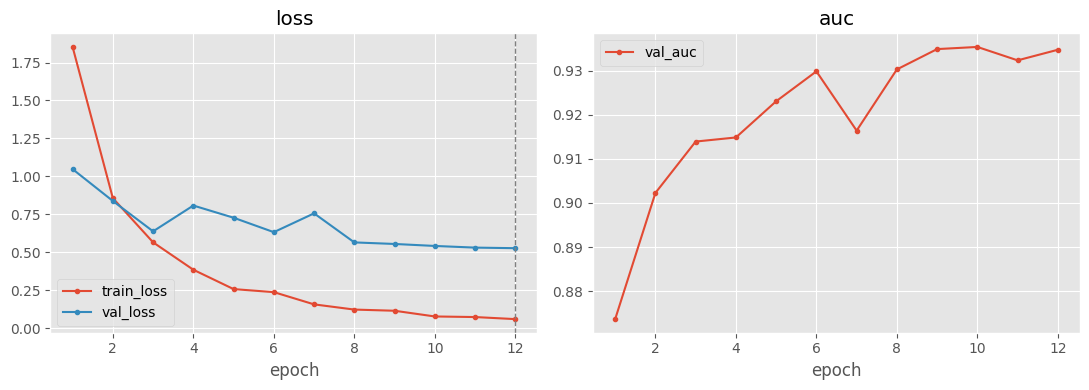

In [6]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 5 - In-distribution evaluation (DIRE test subsample)

tuned threshold: 0.7969


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,2000,1000,1000,0.873,0.872992,0.879065,0.865,0.939858,0.93076,0.746096,0.105783


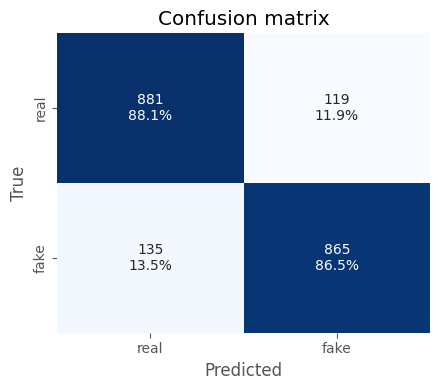

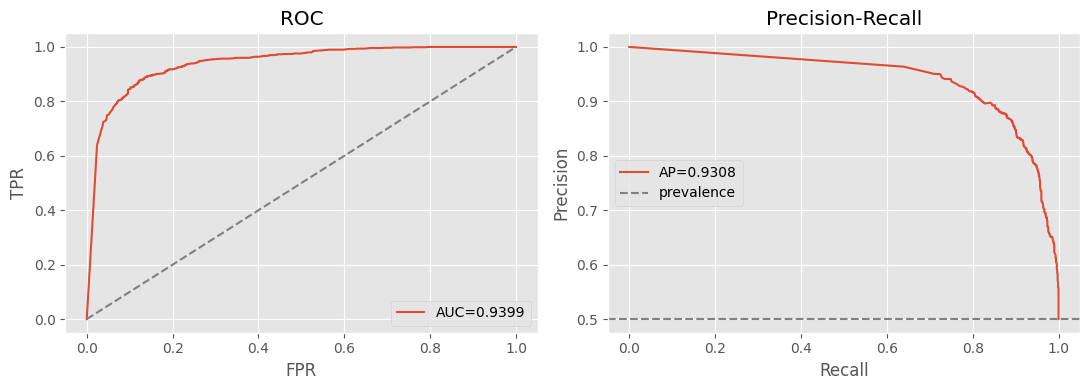

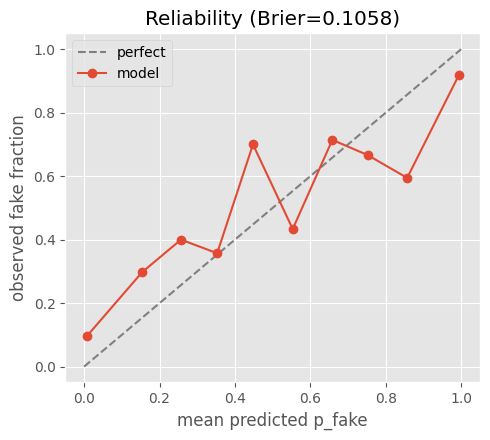

In [7]:
T.load_weights(ckpt_path, model, map_location=device)
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold:", round(tuned["threshold"], 4)); display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Cross-generator (OOD) preview

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0/2000


  100/2000


  200/2000


  300/2000


...

  1700/2000


  1800/2000


  1900/2000


,generator,accuracy,n
0,adm,0.513793,290
1,biggan,0.463768,276
2,glide,0.526946,334
3,midjourney,0.595420,262
4,sdv5,0.580882,272
5,vqdm,0.467857,280
6,wukong,0.646853,286


overall OOD accuracy: 0.5415  (in-dist 0.8730)


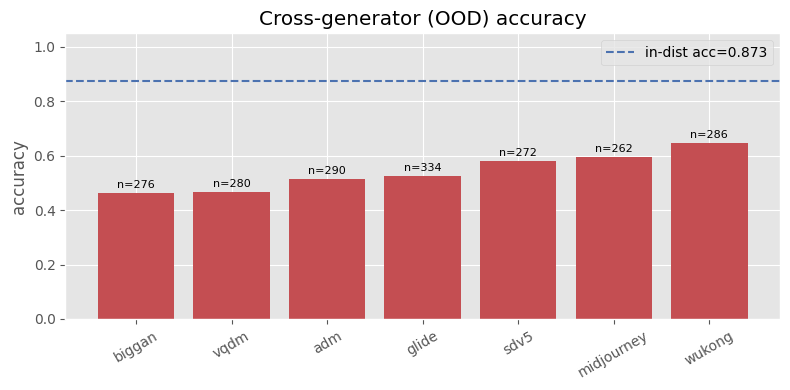

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
oodm = pd.read_csv(TINY_MANIFEST); oodm = oodm[oodm["keep"]]
ood_sub = subsample(oodm, N_OOD)
DIRE_OOD = build_dire_cache(ood_sub, DATA_DIR / "tiny-genimage" / "dire_ood.npy")
LAB_OOD = (ood_sub["label"].values == "fake").astype(np.float32)
ood_loader = torch.utils.data.DataLoader(DireDataset(DIRE_OOD, LAB_OOD, eval_tf), batch_size=BATCH_SIZE * 2, shuffle=False)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_sub = ood_sub.assign(p_fake=po, y_true=yo); ood_sub["y_pred"] = (ood_sub["p_fake"] >= 0.5).astype(int)
ood_sub["generator"] = ood_sub["source"].map(GEN_MAP).fillna(ood_sub["source"])
per_gen = pd.DataFrame([{"generator": g, "accuracy": float((d["y_pred"] == d["y_true"]).mean()), "n": int(len(d))} for g, d in ood_sub.groupby("generator")])
overall_ood = float((ood_sub["y_pred"] == ood_sub["y_true"]).mean())
display(per_gen); print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight"); plt.show()

## 7 - Explainability (DIRE maps)

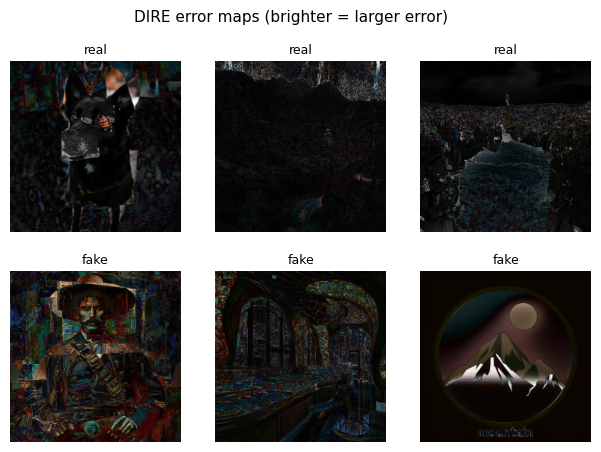

In [9]:
ir = np.where(LAB["test"] == 0)[0][:3]; iff = np.where(LAB["test"] == 1)[0][:3]
fig, axes = plt.subplots(2, 3, figsize=(7.5, 5))
for col, ix in enumerate(ir):
    axes[0, col].imshow(DIRE["test"][ix]); axes[0, col].axis("off"); axes[0, col].set_title("real", fontsize=9)
for col, ix in enumerate(iff):
    axes[1, col].imshow(DIRE["test"][ix]); axes[1, col].axis("off"); axes[1, col].set_title("fake", fontsize=9)
fig.suptitle("DIRE error maps (brighter = larger error)", fontsize=11)
fig.savefig(dirs["figures"] / "dire_maps.png", dpi=150, bbox_inches="tight"); plt.show()

## 8 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE, "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE, "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood, "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()}, "preview": True},
    "tuning": TUNE_SUMMARY,
    "backbone": best["backbone"], "ddim_steps": STEPS, "subsample": {"train": int(len(LAB["train"])), "test": int(len(LAB["test"]))},
    "figures": {k: f"figures/{k}.png" for k in ['training_curves', 'confusion', 'roc_pr', 'reliability', 'ood_per_generator', 'dire_maps']},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\dire-recon\metrics\metrics.json
